#### PIL(Pillow)를 이용한 Image 처리


In [2]:
from PIL import Image

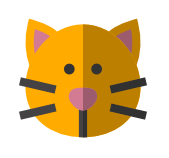

In [3]:
# 이미지 불러오기

cat = Image.open("../Data/cat.png")
cat

In [4]:
# Image 층(Layer) 확인
cat.getbands()

('R', 'G', 'B')

#### Mode
- L : black and white
- RGB : True Color
- RGBA : 투명도가 있는 True Color
- YCbCr : Video

In [5]:
# Size
cat.size

(169, 158)

In [6]:
# File.name
cat.filename

'../Data/cat.png'

In [7]:
# File Format
cat.format

'PNG'

In [ ]:
# Convert to JPEG
cat.save("../Data/cat1.jpg") 
# .png의 이미지가 조금 더 깔끔함
# jpg는 압축데이터다. (원래의 약 80% 정도만 보여줌.)

#### Thumbnail(썸네일) 만들기
- 가로와 세로의 크기를 반으로 줄인다.
- 반으로 줄이면 실수(Real Number)가 발생할 수 있어 소수점 이하는 truncate(버림)한다.

In [13]:
import math 

In [ ]:
math.trunc(cat.size[0] / 2) # 소수점 버림
# 결과값 -> 튜플


84

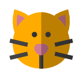

In [21]:
# thumbnail 만들기
size = math.trunc(cat.size[0] / 2), math.trunc(cat.size[1] / 2)
catThumb = cat.copy()
catThumb.thumbnail(size)
catThumb.save("../Data/thumb.png")
catThumb



----
#### Image Manipulation

##### Image Crop

In [23]:
# 이미지 크기
print('전체크기:', cat.size)
print('가로크기:', cat.width)
print('세로크기:', cat.height)

전체크기: (169, 158)
가로크기: 169
세로크기: 158


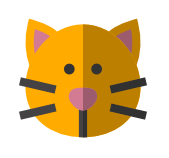

In [24]:
cat

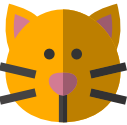

In [25]:
box = (20,15,147,140) # x좌표, y좌표, x크기, y크기
catcrop = cat.crop(box)
catcrop

#### Image Rotation


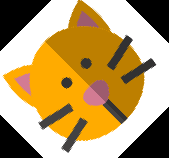

In [27]:
catRotate = cat.rotate(45) # 각도
catRotate

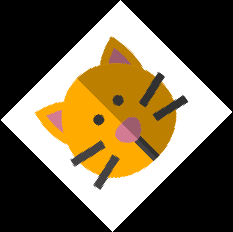

In [29]:
catRotate = cat.rotate(45, expand=True)
catRotate

#### Image Merge

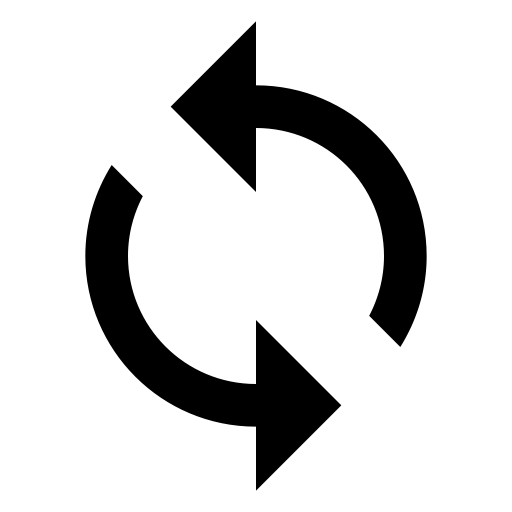

In [ ]:
record = Image.open("../Data/record.png")
record

In [32]:
# mode 확인
record.mode

'RGBA'

In [33]:
# 크기확인
record.size

(512, 512)

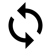

In [36]:
# 이미지 크기가 cat보다 커서 줄이자
# 1/10 크기로 줄여서 recordThumb를 만들자

size = math.trunc(record.width / 10), math.trunc(record.height / 10)
recordThumb = record.copy()
recordThumb.thumbnail(size)
recordThumb.save("../Data/recordThumb.png")
recordThumb

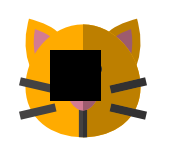

In [37]:
# cat(169,158) 위에 recordThumb를 배치
position = (50,50)
catMerge = cat.copy()
catMerge.paste(recordThumb, position)
catMerge

> recordThumb의 배경색은 투명(검은색)이고 이미지도 검은색
검은색 투명도 제거

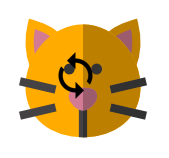

In [38]:
# cat(169,158) 위에 recordThumb를 배치
position = (50,50)
catMerge = cat.copy()
catMerge.paste(recordThumb, position, recordThumb)
catMerge

#### Center에 배치

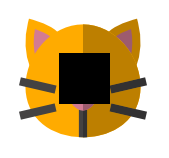

In [40]:
# cat(169,158) 위에 recordThumb를 배치
# cat 위에 recordThumb를 정중앙에 배치
position = (math.trunc((cat.width - recordThumb.width) / 2),
            math.trunc((cat.height - recordThumb.height) / 2))
catMerge = cat.copy()
catMerge.paste(recordThumb, position)
catMerge


#### Image Flip

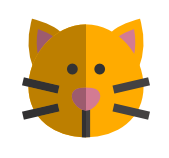

In [45]:
catFlip = cat.copy()
catFlip.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

# 좌우 반전

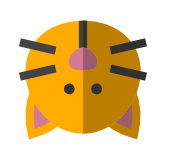

In [46]:
catFlip = cat.copy()
catFlip.transpose(Image.Transpose.FLIP_TOP_BOTTOM)

# 상하 반전

#### PIL Image to Numpy array

In [47]:
import numpy as np

In [49]:
cat_array = np.array(cat)
cat_array

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [50]:
cat_array.shape

(158, 169, 3)

In [51]:
# Numpy array -> Image
img = Image.fromarray(cat_array, 'RGB')
img.save("../Data/cat_array.png")
img.show()


In [52]:
# 특정 pixel의 RGB값 확인
cat.getpixel((70,70))

(51, 51, 51)

#### Color Transformation

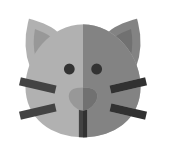

In [53]:
# RGB -> 흑백
cat.convert("L")

----
#### ImageEnhance

In [54]:
from PIL import ImageEnhance

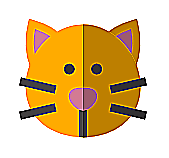

In [ ]:
# image sharpness
enhance = ImageEnhance.Sharpness(cat) # 이미지 선명도
enhance.enhance(10)

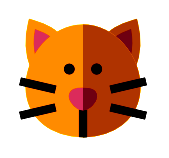

In [58]:
# image contrast
enhance = ImageEnhance.Contrast(cat) # 이미지 대비
enhance.enhance(2)

----
#### Filters

In [59]:
from PIL import ImageFilter

# Blur

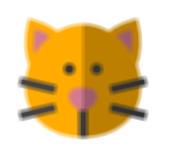

In [60]:
cat.filter(ImageFilter.BLUR)

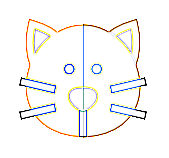

In [62]:
# Contour
cat.filter(ImageFilter.CONTOUR) # 이미지 형태

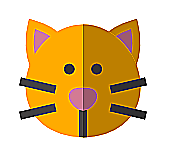

In [64]:
# Edge Enhance
cat.filter(ImageFilter.EDGE_ENHANCE)

#### Find Edge

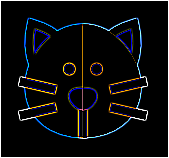

In [63]:
cat.filter(ImageFilter.FIND_EDGES)

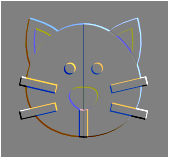

In [ ]:
# Emboss 
# Edge에서 확장 -> 3차원
cat.filter(ImageFilter.EMBOSS)

----
#### Augmented Image 증강(유사 이미지 증강)

In [66]:
from PIL import Image

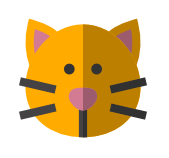

In [68]:
img = Image.open("../Data/cat.png")
img

In [69]:
# 회전 데이터 추가
counter = 0

for angle in range(-15,15,1):
   counter+=1
   img2 = img.rotate(angle)
   img2.save(f"../Data/Cat/rotation_{counter}.png")

   # 반전 데이터 추가
   img3 = img2.transpose(Image.FLIP_LEFT_RIGHT)
   img3.save(f"../Data/Cat/flip_{counter}.png")

In [72]:
import numpy as np
list(np.arange(1,10,0.5)) # 실수도 증가할 수 있는건 numpy 뿐임

[1.0,
 1.5,
 2.0,
 2.5,
 3.0,
 3.5,
 4.0,
 4.5,
 5.0,
 5.5,
 6.0,
 6.5,
 7.0,
 7.5,
 8.0,
 8.5,
 9.0,
 9.5]

In [73]:
import numpy as np

for angle in np.arange(-15,15,0.5):
   counter+=1
   img2 = img.rotate(angle)
   img2.save(f"../Data/Cat/rotation_{counter}.png")

   # 반전 데이터 추가
   img3 = img2.transpose(Image.FLIP_LEFT_RIGHT)
   img3.save(f"../Data/Cat/flip_{counter}.png")